# House prices in Stockton and a finite Markov model of traffic

**Final practical project**

| | |
|---|---|
| **Author** | Nguyễn Thế Hiển |
| **Student ID** | 22127107 |
| **Class** | 22TTH |

---

## Abstract

This report treats two quantitative problems. First, we estimate linear predictors of residential selling prices in Stockton, California, by ordinary least squares (OLS). Candidate specifications — univariate, multivariate, logarithmic, and polynomial — are ranked by the Euclidean residual norm on the original dollar scale. Living area is the dominant covariate; among the models examined, a quadratic specification with lot-size and pool interactions attains the smallest residual. Second, we construct a three-state Markov chain from a simulated 60-day traffic record, obtain the maximum-likelihood transition matrix, and compute both the $k$-step distribution and the stationary distribution. All estimators are implemented from the defining matrix equations; external libraries are used only to read the sample, plot figures, represent matrices, and generate the simulated path.

**Keywords.** ordinary least squares; residual norm; polynomial regression; finite Markov chain; stationary distribution

## Notation and software

Throughout, $y\in\mathbb{R}^n$ denotes the response, $X\in\mathbb{R}^{n\times (p+1)}$ the design matrix including a leading column of ones, and $\theta\in\mathbb{R}^{p+1}$ the parameter. Fitted values are $\hat y = X\hat\theta$ and residuals $e = y-\hat y$. Matrix algebra is carried out in NumPy; tabular input uses pandas; figures use Matplotlib.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import matrix_power
from matplotlib.patches import Patch

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 20)

plt.rcParams.update({
    "font.family": ["Times New Roman", "Arial Unicode MS", "DejaVu Serif"],
    "axes.unicode_minus": False,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "figure.titlesize": 12,
})

C_MAIN = "#1f4e79"
C_ACCENT = "#c45911"
C_OK = "#2e7d32"

In [2]:
def add_intercept(X):
    """Augment the design matrix by a leading column of ones (intercept)."""
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return np.column_stack([np.ones(X.shape[0]), X])


def fit_ols(X, y):
    """OLS estimator obtained by solving the normal equation (XᵀX)θ = Xᵀy."""
    X_ = add_intercept(X)
    y = np.asarray(y, dtype=float).ravel()
    XtX = np.dot(X_.T, X_)
    Xty = np.dot(X_.T, y)
    try:
        theta = np.linalg.solve(XtX, Xty)
    except np.linalg.LinAlgError:
        theta, *_ = np.linalg.lstsq(X_, y, rcond=None)
    return theta


def predict(X, theta):
    """Compute fitted values ŷ = Xθ on the intercept-augmented design."""
    return np.dot(add_intercept(X), np.asarray(theta, dtype=float))


def residual_norm(y, y_hat):
    """Euclidean residual magnitude ‖y − ŷ‖₂, the official ranking criterion."""
    e = np.asarray(y, dtype=float).ravel() - np.asarray(y_hat, dtype=float).ravel()
    return float(np.sqrt(np.sum(e ** 2)))


def rmse(y, y_hat):
    """Root-mean-square error ‖e‖₂ / √n, reported in the unit of y."""
    y = np.asarray(y, dtype=float).ravel()
    return residual_norm(y, y_hat) / np.sqrt(len(y))


def r_squared(y, y_hat):
    """Coefficient of determination R² = 1 − ‖e‖² / ‖y − ȳ‖²."""
    y = np.asarray(y, dtype=float).ravel()
    y_hat = np.asarray(y_hat, dtype=float).ravel()
    e = y - y_hat
    sst = np.sum((y - y.mean()) ** 2)
    return float(1.0 - np.sum(e ** 2) / sst)


def evaluate(y, y_hat):
    """Return residual norm, RMSE, and R² on the original scale of y."""
    return {
        "‖e‖₂": residual_norm(y, y_hat),
        "RMSE": rmse(y, y_hat),
        "R²": r_squared(y, y_hat),
    }


def plot_actual_vs_predicted(ax, y, y_hat, title):
    """Scatter of observed versus fitted values with the reference line y = ŷ."""
    y = np.asarray(y, dtype=float).ravel()
    y_hat = np.asarray(y_hat, dtype=float).ravel()
    ax.scatter(y, y_hat, s=14, alpha=0.38, c=C_MAIN, linewidths=0)
    lo = min(y.min(), y_hat.min())
    hi = max(y.max(), y_hat.max())
    ax.plot([lo, hi], [lo, hi], color=C_ACCENT, lw=1.6, label="y = ŷ")
    ax.set_xlabel("Observed price (USD)")
    ax.set_ylabel("Fitted price (USD)")
    ax.set_title(title)
    ax.legend(frameon=False, loc="upper left")

# 1. Predicting house prices in Stockton

## 1.1 Sample and model

The working file `stockton4.csv` contains $n=1500$ residential transactions in Stockton, California, recorded between 1 October 1996 and 30 November 1998 (Knight, University of the Pacific; a subset of `stockton3`). The response is selling price `sprice` (USD). Covariates are as follows.

| Symbol | Variable | Definition |
|---|---|---|
| $x_1$ | `livarea` | Living area, in hundreds of square feet |
| $x_2$ | `beds` | Number of bedrooms |
| $x_3$ | `baths` | Number of bathrooms (half-baths permitted) |
| $x_4$ | `lgelot` | Indicator of lot size $> 0.5$ acre |
| $x_5$ | `age` | Age of the dwelling at sale, in years |
| $x_6$ | `pool` | Indicator of a swimming pool |

The linear specification is
$$\text{sprice}_i = \theta_0 + \sum_{j=1}^{p}\theta_j x_{ij} + \varepsilon_i,\qquad i=1,\ldots,n.$$
The OLS estimator solves $(X^\top X)\hat\theta = X^\top y$ rather than forming $(X^\top X)^{-1}$ explicitly. Models are compared by
$$\lVert e \rVert_2 = \lVert y-X\hat\theta \rVert_2.$$
RMSE $=\lVert e \rVert_2/\sqrt{n}$ and $R^2$ are reported as descriptive companions; they do not replace $\lVert e \rVert_2$ as the ranking criterion. When a model is fitted to $\log y$, predictions are mapped back by $\hat y = \exp(X\hat\theta)$ before the residual is computed, so that every specification is scored in dollars.

## 1.a Exploratory analysis

In [3]:
df = pd.read_csv("stockton4.csv")
print("Sample size and dimension:", df.shape)
print("\nStorage types:\n", df.dtypes)
print("\nMissing counts:\n", df.isna().sum())
df.head()

Sample size and dimension: (1500, 7)

Storage types:
 sprice       int64
livarea      int64
beds         int64
baths      float64
lgelot       int64
age          int64
pool         int64
dtype: object

Missing counts:
 sprice     0
livarea    0
beds       0
baths      0
lgelot     0
age        0
pool       0
dtype: int64


,sprice,livarea,beds,baths,lgelot,age,pool
0,138000,17,3,2.0000,1,97,0
1,105700,21,4,2.5000,0,18,0
2,22000,7,2,1.0000,0,49,0
3,255000,30,3,3.0000,1,23,0
4,203000,21,4,2.0000,1,18,0


In [4]:
summary = df.describe().T
summary["cv"] = summary["std"] / summary["mean"]
summary

,count,mean,std,min,25%,50%,75%,max,cv
sprice,"1,500.0000","123,693.8513","63,250.8898","22,000.0000","88,000.0000","109,500.0000","135,000.0000","713,000.0000",0.5114
livarea,"1,500.0000",16.7467,5.4620,7.0000,13.0000,16.0000,19.0000,49.0000,0.3262
beds,"1,500.0000",3.2853,0.6198,1.0000,3.0000,3.0000,4.0000,6.0000,0.1887
baths,"1,500.0000",2.1330,0.5254,1.0000,2.0000,2.0000,2.5000,6.5000,0.2463
lgelot,"1,500.0000",0.0633,0.2436,0.0000,0.0000,0.0000,0.0000,1.0000,3.8470
age,"1,500.0000",21.8600,13.1146,0.0000,12.0000,19.0000,31.0000,97.0000,0.5999
pool,"1,500.0000",0.0653,0.2472,0.0000,0.0000,0.0000,0.0000,1.0000,3.7836


In [5]:
print("Frequency of lgelot:\n", df["lgelot"].value_counts().sort_index())
print("\nFrequency of pool:\n", df["pool"].value_counts().sort_index())
print("\nObserved bedroom counts:", np.sort(df["beds"].unique()))
print("Observed bathroom counts:", np.sort(df["baths"].unique()))
print("Dwellings with age 0:", int((df["age"] == 0).sum()))

Frequency of lgelot:
 lgelot
0    1405
1      95
Name: count, dtype: int64

Frequency of pool:
 pool
0    1402
1      98
Name: count, dtype: int64

Observed bedroom counts: [1 2 3 4 5 6]
Observed bathroom counts: [1.  1.5 2.  2.5 3.  3.5 4.  4.5 6.5]
Dwellings with age 0: 24


**Table 1** reports location and scale. The sample is complete (no missing entries). Mean price is $\$123{,}694$ against a median of $\$109{,}500$ and a maximum of $\$713{,}000$: the marginal distribution of `sprice` is right-skewed. Mean living area is $16.75$ hundred square feet (approximately $1{,}675$ ft$^2$). Three- and four-bedroom, two-bathroom houses dominate. Large lots and pools are uncommon (about $6.3\%$ and $6.5\%$), so the corresponding coefficients will be estimated from a thin treated subsample.

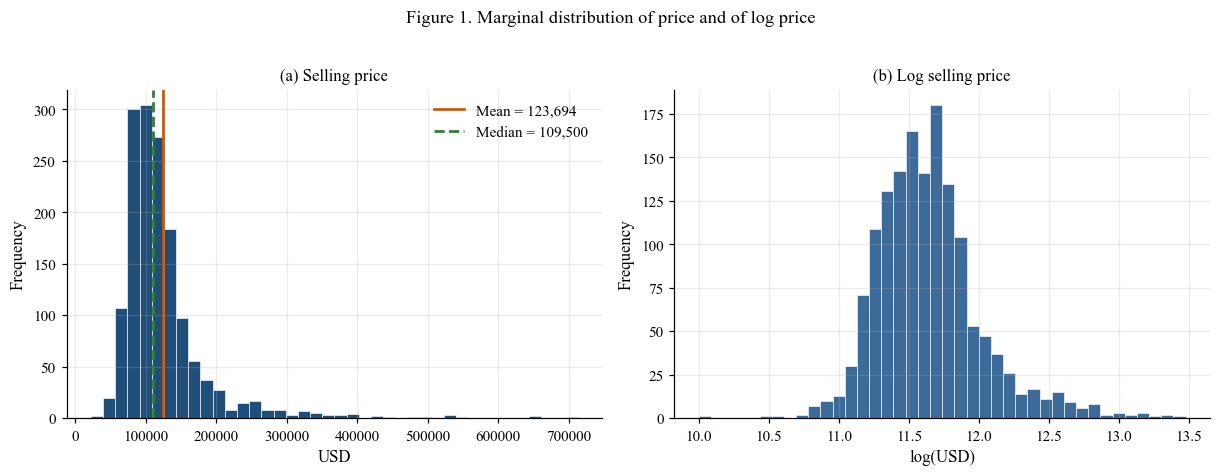

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2))

axes[0].hist(df["sprice"], bins=40, color=C_MAIN, edgecolor="white", linewidth=0.4)
axes[0].axvline(df["sprice"].mean(), color=C_ACCENT, lw=1.8,
                label=f"Mean = {df['sprice'].mean():,.0f}")
axes[0].axvline(df["sprice"].median(), color=C_OK, lw=1.8, ls="--",
                label=f"Median = {df['sprice'].median():,.0f}")
axes[0].set_title("(a) Selling price")
axes[0].set_xlabel("USD")
axes[0].set_ylabel("Frequency")
axes[0].legend(frameon=False)

axes[1].hist(np.log(df["sprice"]), bins=40, color="#3d6b99", edgecolor="white", linewidth=0.4)
axes[1].set_title("(b) Log selling price")
axes[1].set_xlabel("log(USD)")
axes[1].set_ylabel("Frequency")

fig.suptitle("Figure 1. Marginal distribution of price and of log price", y=1.02)
fig.tight_layout()
plt.show()

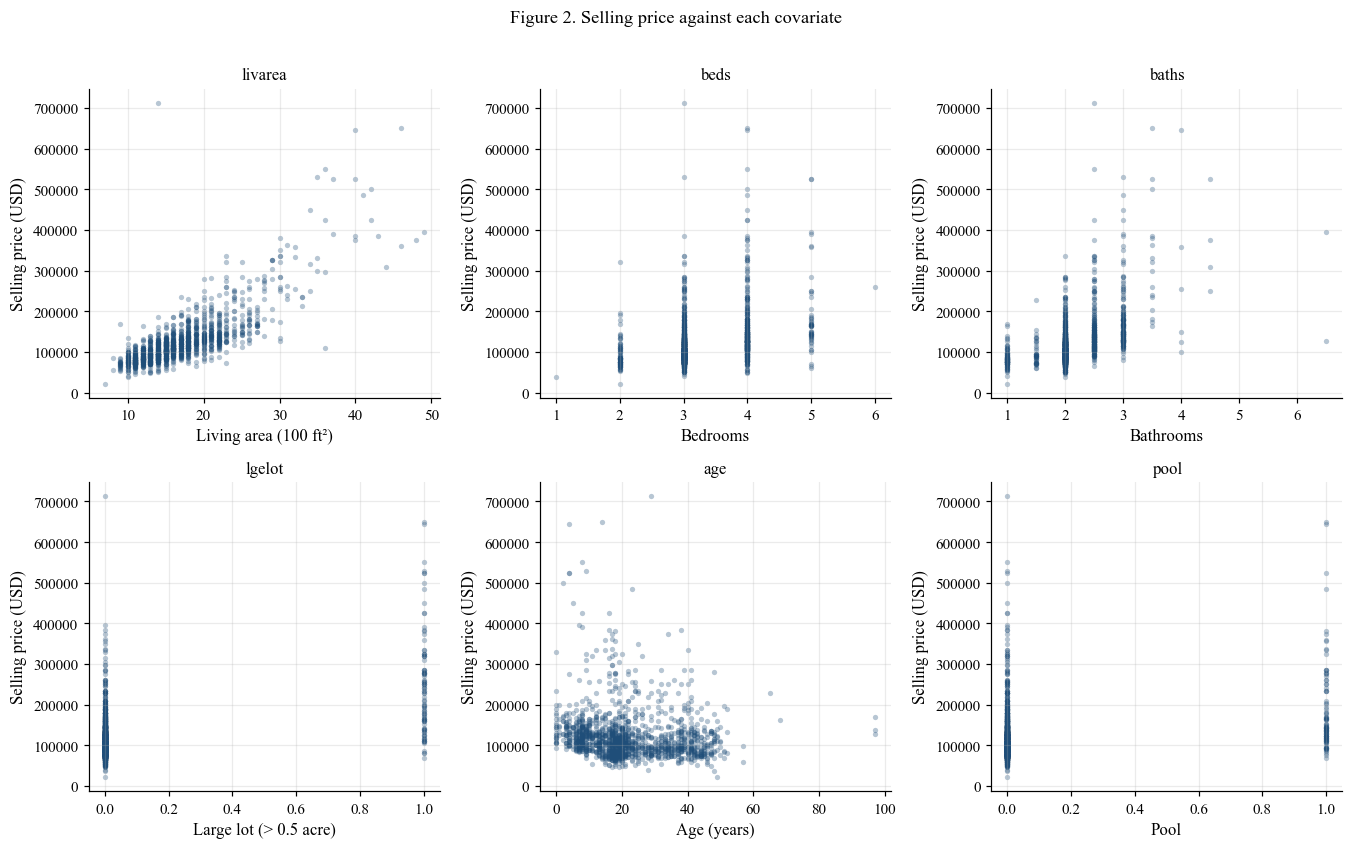

In [7]:
features = ["livarea", "beds", "baths", "lgelot", "age", "pool"]
labels = {
    "livarea": "Living area (100 ft²)",
    "beds": "Bedrooms",
    "baths": "Bathrooms",
    "lgelot": "Large lot (> 0.5 acre)",
    "age": "Age (years)",
    "pool": "Pool",
}

fig, axes = plt.subplots(2, 3, figsize=(12.4, 7.6))
for ax, col in zip(axes.ravel(), features):
    ax.scatter(df[col].values, df["sprice"].values, s=12, alpha=0.32, c=C_MAIN, linewidths=0)
    ax.set_xlabel(labels[col])
    ax.set_ylabel("Selling price (USD)")
    ax.set_title(col)

fig.suptitle("Figure 2. Selling price against each covariate", y=1.01)
fig.tight_layout()
plt.show()

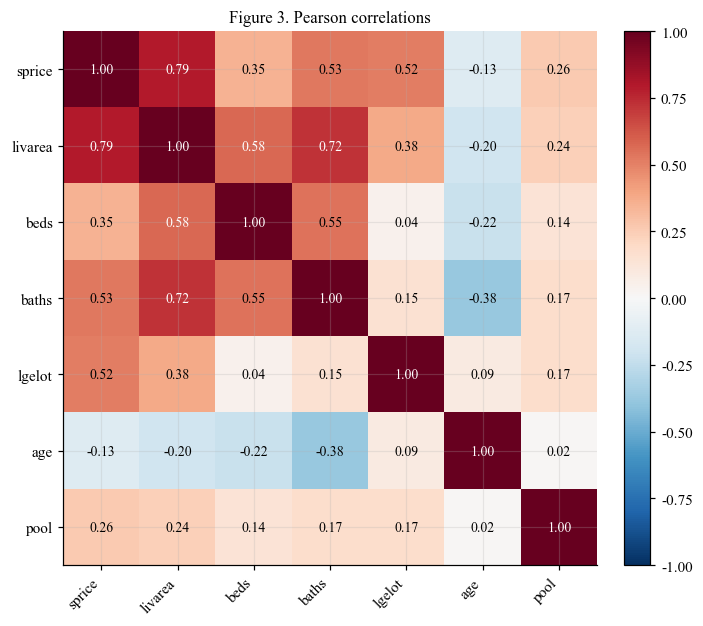

Correlation with sprice:
sprice     1.0000
livarea    0.7929
baths      0.5267
lgelot     0.5154
beds       0.3469
pool       0.2617
age       -0.1300


In [8]:
corr = df.corr(numeric_only=True)
corr_sprice = corr["sprice"].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6.8, 5.8))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
ax.set_title("Figure 3. Pearson correlations")
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(corr.values[i, j]) > 0.55 else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

print("Correlation with sprice:")
print(corr_sprice.to_string())

Figure 1 confirms skewness in `sprice` and a more symmetric profile after the logarithm — a reason to try log-linear models in Section 1.d. Pairwise associations in Figures 2–3 are as follows.

- `livarea` has the strongest linear association with price ($r \approx 0.79$). The scatter is increasing and approximately linear.
- `baths` ($r \approx 0.53$) and `lgelot` ($r \approx 0.52$) follow. Large lots are rare but occupy the upper tail of the price distribution.
- `beds` ($r \approx 0.35$) is weaker. `beds`, `baths`, and `livarea` are mutually correlated, so a multiple regression will be collinear in the size block.
- `pool` is moderately positive ($r \approx 0.26$).
- `age` is weakly negative ($r \approx -0.13$).

A priori, the leading univariate regressor should be `livarea`; lot size, pool, and age are the covariates most likely to reduce the residual further.

## 1.b Univariate specifications

For each covariate $x$ we estimate
$$\text{sprice} = \theta_0 + \theta_1 x + \varepsilon$$
and record $\lVert e \rVert_2$, RMSE, and $R^2$.

In [9]:
y = df["sprice"].values.astype(float)
single_rows = []
single_models = {}

for col in features:
    X = df[col].values
    theta = fit_ols(X, y)
    y_hat = predict(X, theta)
    metrics = evaluate(y, y_hat)
    single_models[col] = {"theta": theta, "y_hat": y_hat, **metrics}
    single_rows.append({
        "Covariate": col,
        "θ₀": theta[0],
        "θ₁": theta[1],
        "‖e‖₂": metrics["‖e‖₂"],
        "RMSE (USD)": metrics["RMSE"],
        "R²": metrics["R²"],
    })

single_table = pd.DataFrame(single_rows).sort_values("‖e‖₂")
single_table

,Covariate,θ₀,θ₁,‖e‖₂,RMSE (USD),R²
0,livarea,"-30,069.1996","9,181.7108","1,492,302.8600","38,531.0942",0.6287
2,baths,"-11,555.8809","63,408.2195","2,081,735.4287","53,750.1776",0.2774
3,lgelot,"115,220.0192","133,797.3492","2,098,584.3425","54,185.2147",0.2656
1,beds,"7,392.9485","35,400.0313","2,296,811.7452","59,303.4243",0.1203
5,pool,"119,318.6933","66,966.7047","2,363,522.8042","61,025.8964",0.0685
4,age,"137,403.5904",-627.1610,"2,428,086.4662","62,692.9230",0.0169


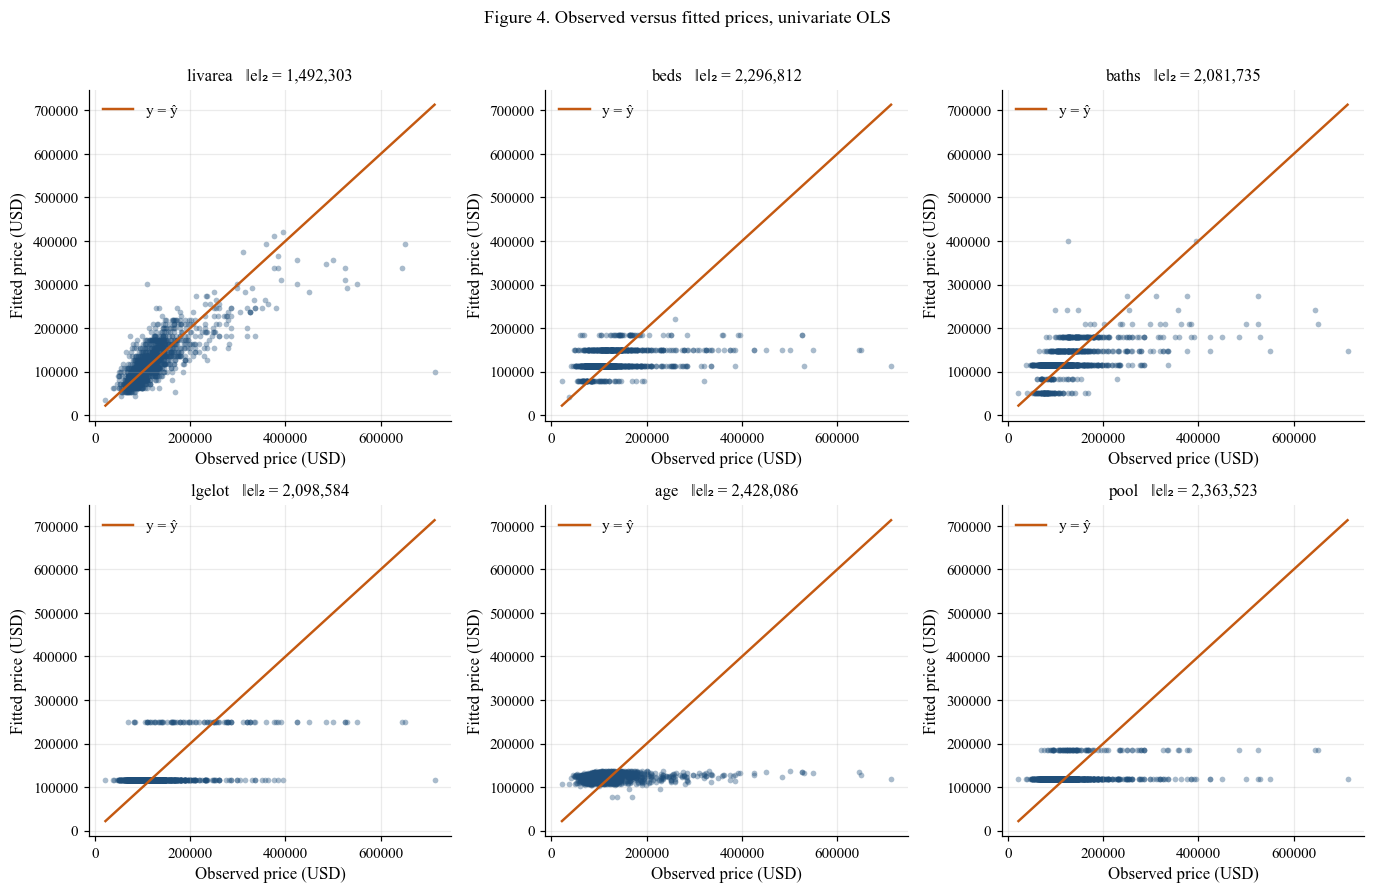

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(12.6, 8.0))
for ax, col in zip(axes.ravel(), features):
    info = single_models[col]
    plot_actual_vs_predicted(
        ax, y, info["y_hat"],
        title=f"{col}   ‖e‖₂ = {info['‖e‖₂']:,.0f}"
    )
fig.suptitle("Figure 4. Observed versus fitted prices, univariate OLS", y=1.01)
fig.tight_layout()
plt.show()

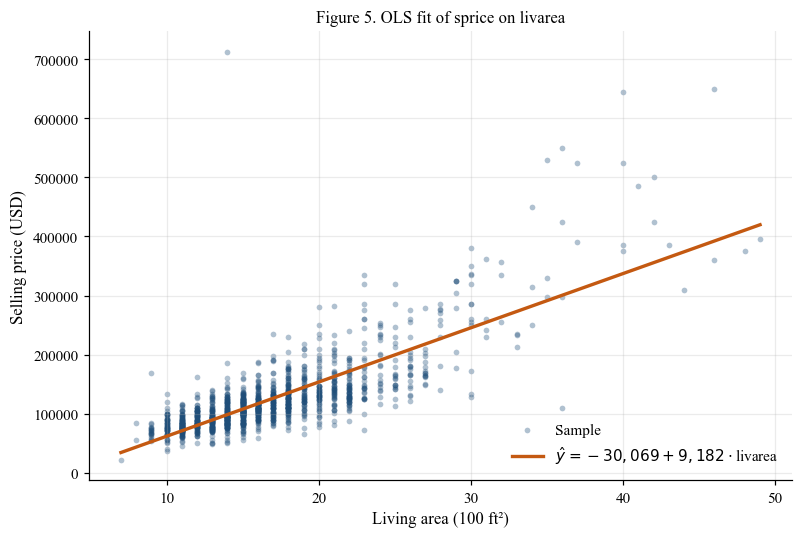

Slope: $9,182 per 100 ft² of living area.


In [11]:
best = "livarea"
th = single_models[best]["theta"]
xs = np.linspace(df[best].min(), df[best].max(), 200)
ys = th[0] + th[1] * xs

fig, ax = plt.subplots(figsize=(7.4, 5.0))
ax.scatter(df[best], y, s=14, alpha=0.35, c=C_MAIN, linewidths=0, label="Sample")
ax.plot(xs, ys, color=C_ACCENT, lw=2.2,
        label=fr"$\hat y = {th[0]:,.0f} + {th[1]:,.0f}\cdot$livarea")
ax.set_xlabel(labels[best])
ax.set_ylabel("Selling price (USD)")
ax.set_title("Figure 5. OLS fit of sprice on livarea")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"Slope: ${th[1]:,.0f} per 100 ft² of living area.")

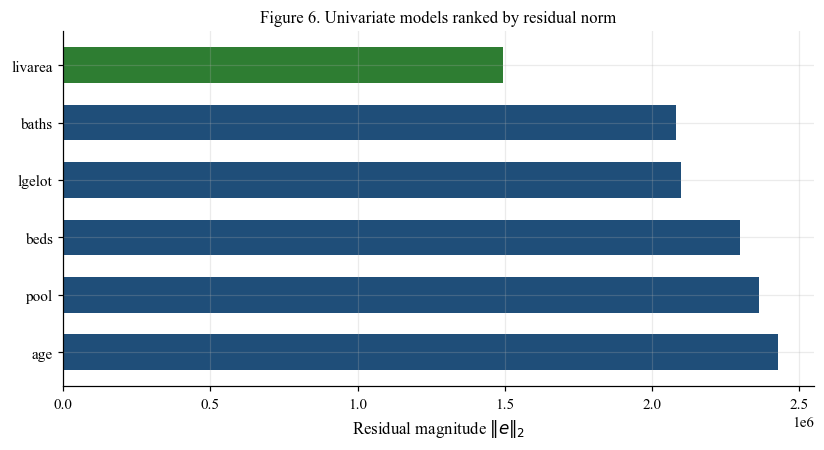

In [12]:
fig, ax = plt.subplots(figsize=(7.6, 4.2))
order = single_table["Covariate"].tolist()
values = single_table["‖e‖₂"].tolist()
colors = [C_OK if c == order[0] else C_MAIN for c in order]
ax.barh(order[::-1], values[::-1], color=colors[::-1], height=0.62)
ax.set_xlabel(r"Residual magnitude $\Vert e\Vert_2$")
ax.set_title("Figure 6. Univariate models ranked by residual norm")
fig.tight_layout()
plt.show()

**Result (b).** Ordered by increasing $\lVert e \rVert_2$:

1. **`livarea`** dominates ($R^2 \approx 0.63$). Fitted values in Figure 4 concentrate about the $45^\circ$ line more closely than for any other single covariate. The slope in Figure 5 is about $\$9{,}182$ per 100 ft$^2$, or roughly $\$92$ per square foot.
2. `baths` and `lgelot` occupy an intermediate rank. Conditional on a single bathroom count or lot class, price remains highly dispersed.
3. `beds`, `pool`, and especially `age` have little univariate content. For age, $\lVert e \rVert_2$ is close to $\lVert y-\bar y \rVert_2$ itself ($R^2 \approx 0.017$).

The univariate benchmark used below is therefore
$$\widehat{\text{sprice}} = \hat\theta_0 + \hat\theta_1\,\text{livarea}.$$

## 1.c Multiple linear specification

We now include the full covariate vector,
$$\text{sprice} = \theta_0 + \theta_1\,\text{livarea} + \theta_2\,\text{beds} + \theta_3\,\text{baths} + \theta_4\,\text{lgelot} + \theta_5\,\text{age} + \theta_6\,\text{pool} + \varepsilon.$$

In [13]:
X_multi = df[features].values
theta_multi = fit_ols(X_multi, y)
y_hat_multi = predict(X_multi, theta_multi)
metrics_multi = evaluate(y, y_hat_multi)

coef_table = pd.DataFrame({
    "Coefficient": ["θ₀ (intercept)"] + [f"θ ({c})" for c in features],
    "Estimate": theta_multi,
})
print("Table 2. OLS estimates, six-covariate linear model")
print(coef_table.to_string(index=False))
print("\nFit:")
for k, v in metrics_multi.items():
    print(f"  {k}: {v:,.6f}" if k == "R²" else f"  {k}: {v:,.2f}")
delta = single_models["livarea"]["‖e‖₂"] - metrics_multi["‖e‖₂"]
pct = 100 * (1 - metrics_multi["‖e‖₂"] / single_models["livarea"]["‖e‖₂"])
print(f"\nReduction in ‖e‖₂ relative to livarea-only: {delta:,.2f} ({pct:.2f}%).")

Table 2. OLS estimates, six-covariate linear model
   Coefficient     Estimate
θ₀ (intercept)  16,031.1133
   θ (livarea)   8,884.4814
      θ (beds) -10,571.8634
     θ (baths)  -3,539.3181
    θ (lgelot)  59,598.0218
       θ (age)    -162.9355
      θ (pool)  14,479.2586

Fit:
  ‖e‖₂: 1,353,756.97
  RMSE: 34,953.85
  R²: 0.694405

Reduction in ‖e‖₂ relative to livarea-only: 138,545.89 (9.28%).


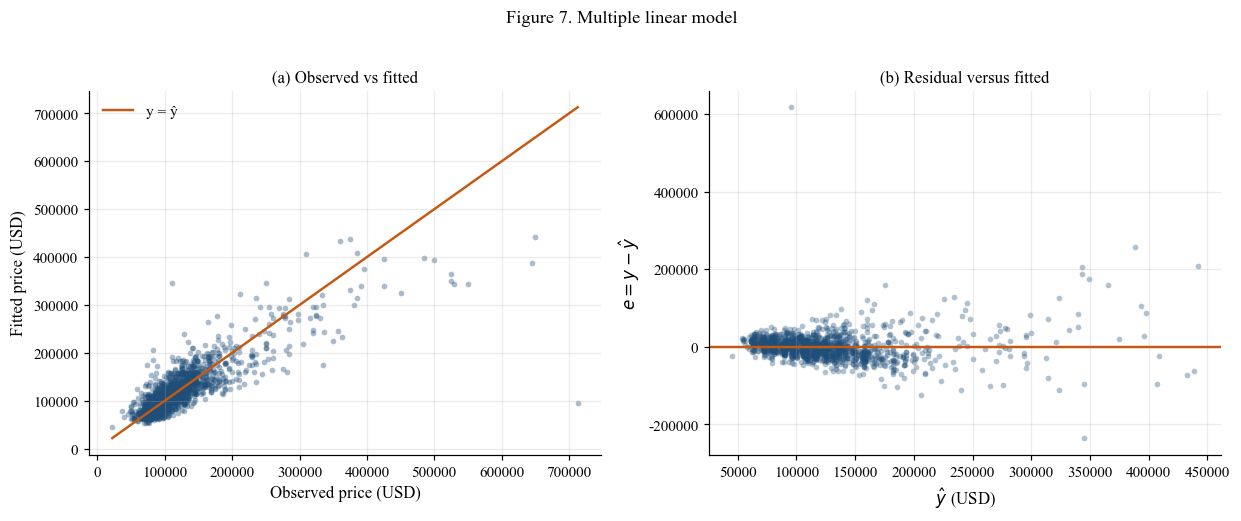

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.6))
plot_actual_vs_predicted(axes[0], y, y_hat_multi, "(a) Observed vs fitted")

e_multi = y - y_hat_multi
axes[1].scatter(y_hat_multi, e_multi, s=14, alpha=0.35, c=C_MAIN, linewidths=0)
axes[1].axhline(0, color=C_ACCENT, lw=1.6)
axes[1].set_xlabel(r"$\hat y$ (USD)")
axes[1].set_ylabel(r"$e = y - \hat y$")
axes[1].set_title("(b) Residual versus fitted")
fig.suptitle("Figure 7. Multiple linear model", y=1.02)
fig.tight_layout()
plt.show()

**Result (c).** The six-covariate fit reduces $\lVert e \rVert_2$ relative to the livarea-only model and raises $R^2$ to approximately $0.69$. Partial effects, holding the remaining covariates fixed, are as follows.

- `livarea` remains the principal positive contribution.
- `lgelot` is large and positive: at given living area, a lot exceeding half an acre commands a substantial premium.
- `pool` is positive but smaller than the lot-size effect.
- `age` is negative, consistent with depreciation.
- `beds` and `baths` change sign relative to the univariate fits. Conditional on living area, additional rooms imply a finer partition of the same floor plate; the market need not pay more, and the estimates are also inflated in variance by collinearity with `livarea`. The negative signs are therefore not to be read as a causal claim that bedrooms reduce price.

Figure 7(b) displays heteroscedasticity: residual spread increases with fitted price, and several observations in the extreme upper tail are under-predicted. These features motivate the transformations in Section 1.d.

## 1.d Transformations of the design

We retain $\lVert e \rVert_2$ on the **dollar** scale as the sole ranking device. Three families are examined.

1. Logarithmic response $\log(\text{sprice})$, suggested by Figure 1. Fitted values are $\hat y=\exp(X\hat\theta)$.
2. Quadratic and logarithmic transforms of `livarea` and `age`. Because age attains zero, we use $\log(1+\text{age})$.
3. Interactions `livarea`$\times$`lgelot` and `livarea`$\times$`pool`, allowing the marginal price of floor area to differ on large lots and on pooled houses.

In [15]:
def fit_original(X, y, name):
    """OLS on the original response; return θ, ŷ, and dollar-scale metrics."""
    theta = fit_ols(X, y)
    y_hat = predict(X, theta)
    return {"name": name, "theta": theta, "y_hat": y_hat, "log_y": False, **evaluate(y, y_hat)}


def fit_log_y(X, y, name):
    """OLS on log y, with ŷ = exp(Xθ) before residual evaluation in dollars."""
    theta = fit_ols(X, np.log(y))
    y_hat = np.exp(predict(X, theta))
    return {"name": name, "theta": theta, "y_hat": y_hat, "log_y": True, **evaluate(y, y_hat)}


liv = df["livarea"].values
beds = df["beds"].values
baths = df["baths"].values
lg = df["lgelot"].values
age = df["age"].values
pool = df["pool"].values
log_liv = np.log(liv)
log_age = np.log1p(age)

candidates = [
    fit_original(liv, y, "Univariate: livarea"),
    fit_original(np.column_stack([liv, beds, baths, lg, age, pool]), y,
                 "Linear multiple (Section 1.c)"),
    fit_log_y(liv, y, "log(sprice) ~ livarea"),
    fit_log_y(log_liv, y, "log(sprice) ~ log(livarea)"),
    fit_original(np.column_stack([liv, liv ** 2]), y, "sprice ~ livarea + livarea²"),
    fit_original(np.column_stack([liv, liv ** 2, lg, age, age ** 2, pool]), y,
                 "Quadratic area and age + lot + pool"),
    fit_original(np.column_stack([liv, liv ** 2, beds, baths, lg, age, age ** 2, pool]), y,
                 "Full quadratic in area and age"),
    fit_original(np.column_stack([liv, liv ** 2, beds, baths, lg, age, age ** 2, pool,
                                  liv * lg, liv * pool]), y,
                 "Quadratic + area×lot and area×pool"),
    fit_log_y(np.column_stack([liv, beds, baths, lg, age, pool]), y,
              "log(sprice) ~ linear covariates"),
    fit_log_y(np.column_stack([log_liv, beds, baths, lg, log_age, pool]), y,
              "log(sprice) ~ log area, rooms, lot, log(1+age), pool"),
    fit_log_y(np.column_stack([log_liv, log_liv ** 2, lg, log_age, pool]), y,
              "log(sprice) ~ quadratic log area + lot + log(1+age) + pool"),
    fit_original(np.column_stack([liv, beds, baths, lg, age, pool, liv * lg]), y,
                 "Linear multiple + area×lot"),
]

table_d = pd.DataFrame([
    {"Specification": m["name"], "‖e‖₂": m["‖e‖₂"], "RMSE (USD)": m["RMSE"], "R²": m["R²"]}
    for m in candidates
]).sort_values("‖e‖₂").reset_index(drop=True)
table_d.index = table_d.index + 1
table_d

,Specification,‖e‖₂,RMSE (USD),R²
1,Quadratic + area×lot and area×pool,"1,312,396.8404","33,885.9407",0.7128
2,Full quadratic in area and age,"1,320,355.1105","34,091.4224",0.7093
3,log(sprice) ~ quadratic log area + lot + log(1...,"1,323,585.1595","34,174.8219",0.7079
4,Quadratic area and age + lot + pool,"1,330,920.7948","34,364.2272",0.7046
5,Linear multiple + area×lot,"1,332,515.1128","34,405.3923",0.7039
6,"log(sprice) ~ log area, rooms, lot, log(1+age)...","1,338,899.6541","34,570.2404",0.7011
7,Linear multiple (Section 1.c),"1,353,756.9712","34,953.8547",0.6944
8,sprice ~ livarea + livarea²,"1,424,574.4259","36,782.3535",0.6616
9,log(sprice) ~ linear covariates,"1,432,609.1539","36,989.8093",0.6578
10,log(sprice) ~ livarea,"1,480,888.0028","38,236.3638",0.6343


Minimum residual specification:
  Quadratic + area×lot and area×pool
  ‖e‖₂ = 1,312,396.84
  RMSE = 33,885.94 USD
  R²   = 0.7128


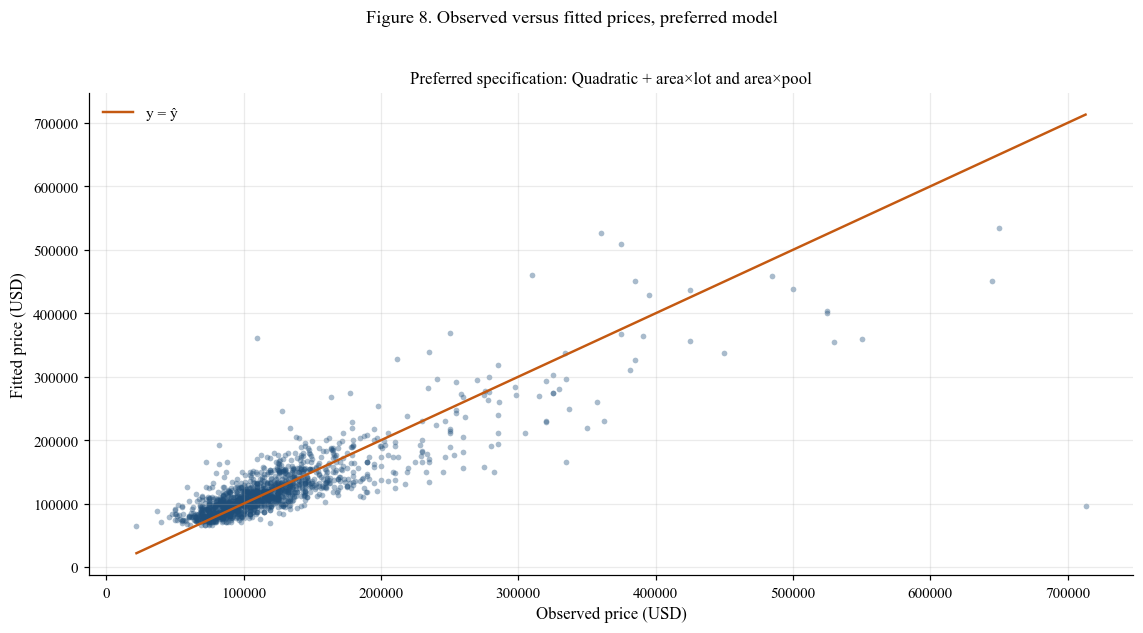

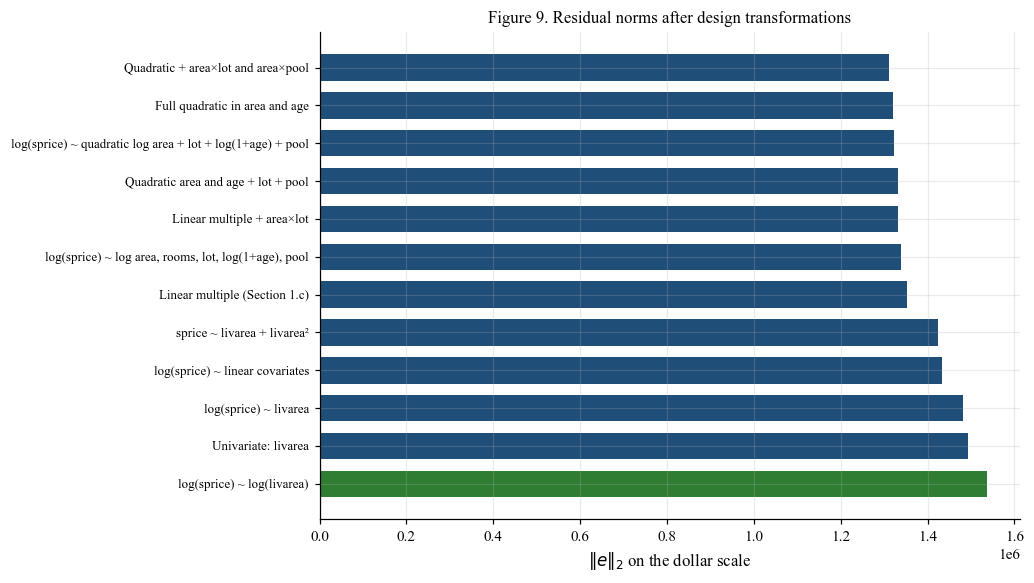

In [16]:
best_model = min(candidates, key=lambda m: m["‖e‖₂"])
print("Minimum residual specification:")
print(" ", best_model["name"])
print(f"  ‖e‖₂ = {best_model['‖e‖₂']:,.2f}")
print(f"  RMSE = {best_model['RMSE']:,.2f} USD")
print(f"  R²   = {best_model['R²']:.4f}")

fig, ax = plt.subplots(figsize=(10.5, 5.6))
plot_actual_vs_predicted(ax, y, best_model["y_hat"],
                         f"Preferred specification: {best_model['name']}")
fig.suptitle("Figure 8. Observed versus fitted prices, preferred model", y=1.02)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 5.4))
names = table_d["Specification"].tolist()[::-1]
ax.barh(range(len(names)), table_d["‖e‖₂"].tolist()[::-1],
        color=[C_OK] + [C_MAIN] * (len(names) - 1), height=0.7)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8.5)
ax.set_xlabel(r"$\Vert e\Vert_2$ on the dollar scale")
ax.set_title("Figure 9. Residual norms after design transformations")
fig.tight_layout()
plt.show()

Estimated θ (intercept first) of the preferred specification:
[ 56718.1385   4402.0088     87.2417  -8169.9364  -1213.2036  17429.1159
   -731.0995     10.9728 -14816.4542   1533.409    1368.8257]


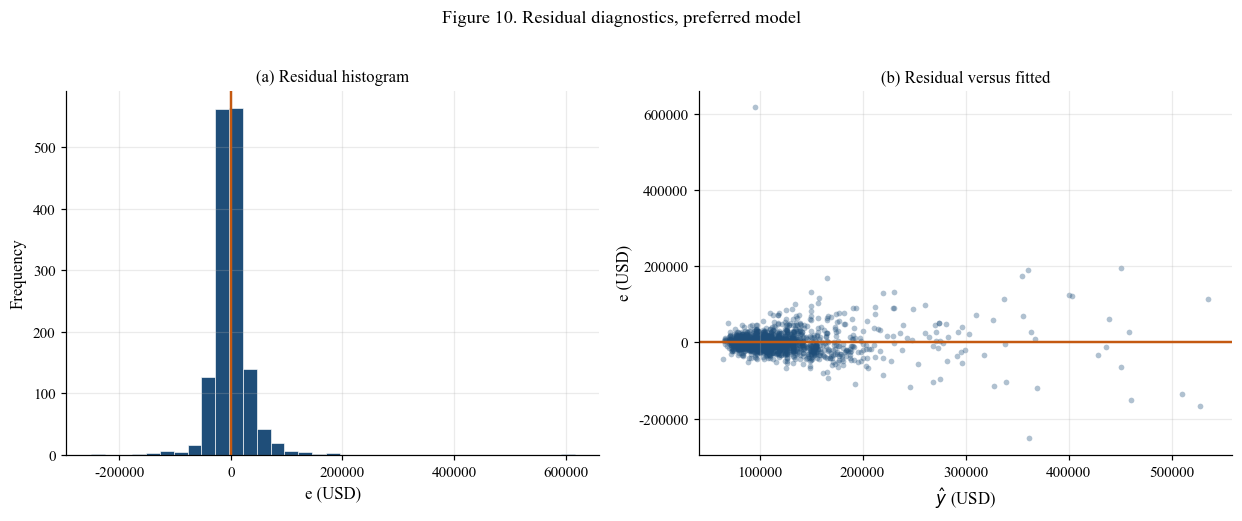

In [17]:
print("Estimated θ (intercept first) of the preferred specification:")
print(best_model["theta"])

e_best = y - best_model["y_hat"]
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.6))
axes[0].hist(e_best, bins=35, color=C_MAIN, edgecolor="white", linewidth=0.4)
axes[0].axvline(0, color=C_ACCENT, lw=1.6)
axes[0].set_title("(a) Residual histogram")
axes[0].set_xlabel("e (USD)")
axes[0].set_ylabel("Frequency")

axes[1].scatter(best_model["y_hat"], e_best, s=14, alpha=0.35, c=C_MAIN, linewidths=0)
axes[1].axhline(0, color=C_ACCENT, lw=1.6)
axes[1].set_xlabel(r"$\hat y$ (USD)")
axes[1].set_ylabel("e (USD)")
axes[1].set_title("(b) Residual versus fitted")
fig.suptitle("Figure 10. Residual diagnostics, preferred model", y=1.02)
fig.tight_layout()
plt.show()

**Result (d) and discussion.** Table 3 (the ranked list above) and Figures 8–9 summarise the comparison.

| Stage | Specification | Role |
|---|---|---|
| 1.b | `sprice ~ livarea` | Best univariate fit |
| 1.c | Linear model in all six covariates | Partial effects of lot, pool, and age |
| 1.d | Quadratics in area and age, plus area–lot and area–pool interactions | Smallest $\lVert e \rVert_2$ in the catalogue |

Two methodological points are worth recording. First, OLS minimises $\sum_i e_i^2$ on the scale to which it is applied. A logarithm can symmetrise Figure 1 yet raise the dollar residual after exponentiation; that outcome is not a contradiction. Second, quadratic terms capture mild curvature in the area–price schedule, while the interactions allow the marginal dollar value of floor area to differ for large-lot and pooled houses.

The comparison is in-sample. Adding terms cannot increase $\lVert e \rVert_2$ on the estimation sample and need not improve prediction for a new transaction. Under the project criterion — minimise residual magnitude on the given $n=1500$ observations — the quadratic-interaction specification is preferred.

# 2. A finite Markov chain for traffic conditions

## 2.1 Framework

Let $\{X_t\}_{t\ge 0}$ be a homogeneous Markov chain on the finite state space $\{\mathrm{K},\mathrm{B},\mathrm{T}\}$, interpreted as congested, normal, and clear traffic on a given arterial. The one-step kernel is $P=(p_{ij})$ with
$$p_{ij}=\mathbb{P}(X_{t+1}=j\mid X_t=i).$$
The $k$-step law is given by the Chapman–Kolmogorov identity
$$\pi^{(k)}=\pi^{(0)}P^k.$$
A stationary distribution $\pi$ solves the eigenproblem $\pi P=\pi$ subject to $\sum_i\pi_i=1$ and $\pi\ge 0$. The functions required by the assignment, `prop_distribution` and `prop_sta`, implement these two objects.

In [18]:
STATES = ["K", "B", "T"]
STATE_LABEL = {"K": "Congested", "B": "Normal", "T": "Clear"}
N_DAYS = 60
SEED = 22127107


def simulate_traffic(n, states, seed):
    """Draw n i.i.d. states, each equally likely on {K, B, T}."""
    rng = np.random.default_rng(seed)
    return rng.choice(states, size=n, replace=True)


def count_transitions(sequence, states):
    """Empirical transition counts C[i,j] from states[i] to states[j]."""
    idx = {s: k for k, s in enumerate(states)}
    m = len(states)
    C = np.zeros((m, m), dtype=float)
    for a, b in zip(sequence[:-1], sequence[1:]):
        C[idx[a], idx[b]] += 1
    return C


def transition_probability(C):
    """Row-normalised maximum-likelihood estimate of P."""
    C = np.asarray(C, dtype=float)
    row = C.sum(axis=1, keepdims=True)
    row[row == 0] = 1.0
    return C / row


def prop_distribution(P, k, p0=None):
    """Law of the chain on day k: π_k = π_0 P^k, with uniform π_0 by default."""
    P = np.asarray(P, dtype=float)
    m = P.shape[0]
    if p0 is None:
        p0 = np.ones(m) / m
    p0 = np.asarray(p0, dtype=float).ravel()
    return np.dot(p0, matrix_power(P, int(k)))


def prop_sta(P):
    """Stationary distribution: solve πP = π together with ∑π_i = 1."""
    P = np.asarray(P, dtype=float)
    m = P.shape[0]
    A = P.T - np.eye(m)
    A[-1, :] = 1.0
    b = np.zeros(m)
    b[-1] = 1.0
    return np.linalg.solve(A, b)


def labeled_matrix(M, states, row_name="from \\ to"):
    """Tabulate a square matrix with state labels on both axes."""
    out = pd.DataFrame(M, index=states, columns=states)
    out.index.name = row_name
    return out

## 2.a Simulated trajectory

The assignment requires a 60-day record in which the three states are equally likely on each day. We therefore draw $X_1,\ldots,X_{60}$ independently and uniformly on $\{\mathrm{K},\mathrm{B},\mathrm{T}\}$, with seed equal to the student identifier so that the path is reproducible. Under this design the true kernel is $p_{ij}=1/3$ for all $i,j$, and the unique stationary law is uniform. The empirical $\hat P$ computed below is then a sampling fluctuation about that kernel, not evidence of serial dependence.

In [19]:
sequence = simulate_traffic(N_DAYS, STATES, SEED)

print(f"Length of the record: {len(sequence)} days")
print("Realisation (10 days per line):")
for i in range(0, N_DAYS, 10):
    print("  " + " ".join(sequence[i:i + 10]))

freq = pd.Series(sequence).value_counts().reindex(STATES)
freq_table = pd.DataFrame({
    "State": [STATE_LABEL[s] for s in STATES],
    "Days": freq.values,
    "Share": freq.values / N_DAYS,
})
freq_table

Length of the record: 60 days
Realisation (10 days per line):
  T T K B K T K K K B
  T T K K K B B K T K
  B B K B B T K B K T
  B T T B T T B T K T
  B K B K T K K T T K
  B B T B K T K T T B


,State,Days,Share
0,Congested,21,0.3500
1,Normal,18,0.3000
2,Clear,21,0.3500


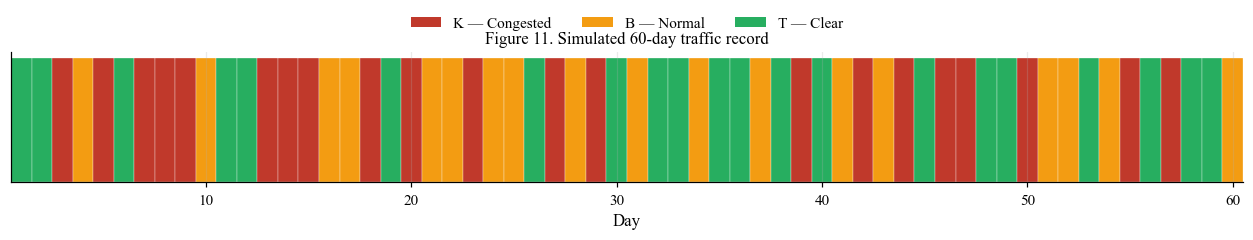

In [20]:
fig, ax = plt.subplots(figsize=(11.5, 2.6))
state_color = {"K": "#c0392b", "B": "#f39c12", "T": "#27ae60"}
for t, st in enumerate(sequence):
    ax.bar(t + 1, 1, color=state_color[st], width=1.0, edgecolor="white", linewidth=0.2)
ax.set_xlim(0.5, N_DAYS + 0.5)
ax.set_yticks([])
ax.set_xlabel("Day")
ax.set_title("Figure 11. Simulated 60-day traffic record")
ax.legend(handles=[Patch(facecolor=state_color[s],
                         label=f"{s} — {STATE_LABEL[s]}") for s in STATES],
          frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.38))
fig.tight_layout()
plt.show()

## 2.b Transition counts

From the length-$60$ path there are $59$ consecutive pairs. The count $C_{ij}$ is the number of observed moves $i\to j$.

In [21]:
C = count_transitions(sequence, STATES)
print("Sum of counts (required: 59):", int(C.sum()))
print("Row totals (departures):", dict(zip(STATES, C.sum(axis=1))))
labeled_matrix(C.astype(int), STATES)

Sum of counts (required: 59): 59
Row totals (departures): {'K': np.float64(21.0), 'B': np.float64(17.0), 'T': np.float64(21.0)}


,K,B,T
from \ to,,,
K,5,8,8
B,7,4,6
T,9,6,6


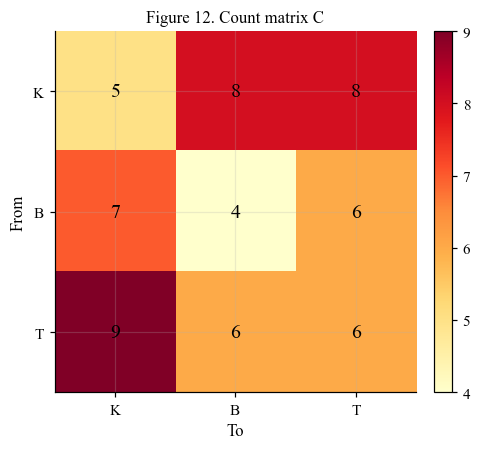

In [22]:
fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(C, cmap="YlOrRd")
ax.set_xticks(range(3), STATES)
ax.set_yticks(range(3), STATES)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_title("Figure 12. Count matrix C")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{int(C[i, j])}", ha="center", va="center", fontsize=13)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## 2.c Estimated transition kernel

The maximum-likelihood estimator of a homogeneous kernel on a single realised path is the row normalisation
$$\hat p_{ij} = \frac{C_{ij}}{\sum_{j'} C_{ij'}}.$$
Row $i$ of $\hat P$ is the estimated conditional law of $X_{t+1}$ given $X_t=i$.

In [23]:
P = transition_probability(C)
print("Row sums (required: 1):", P.sum(axis=1))
labeled_matrix(P, STATES)

Row sums (required: 1): [1. 1. 1.]


,K,B,T
from \ to,,,
K,0.2381,0.3810,0.3810
B,0.4118,0.2353,0.3529
T,0.4286,0.2857,0.2857


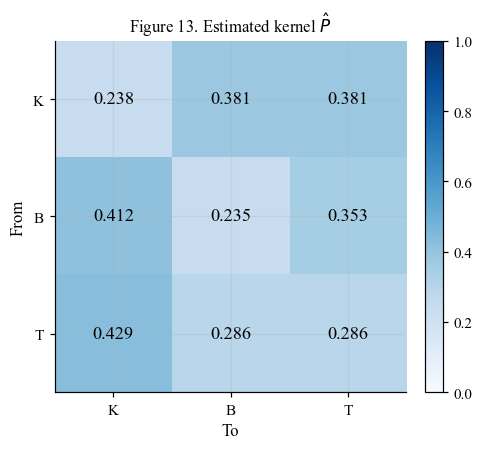

In [24]:
fig, ax = plt.subplots(figsize=(5.0, 4.2))
im = ax.imshow(P, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(3), STATES)
ax.set_yticks(range(3), STATES)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_title(r"Figure 13. Estimated kernel $\hat P$")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{P[i, j]:.3f}", ha="center", va="center", fontsize=12,
                color="white" if P[i, j] > 0.45 else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## 2.d Finite-horizon distribution: `prop_distribution`

The assignment fixes an uninformative initial law $\pi^{(0)}=(1/3,1/3,1/3)$. We evaluate $\pi^{(k)}=\pi^{(0)}\hat P^k$ at $k\in\{1,2,3,10\}$.

In [25]:
p0 = np.array([1 / 3, 1 / 3, 1 / 3])
print("π(0) (uniform):", p0)

rows = []
for k in [1, 2, 3, 10]:
    pk = prop_distribution(P, k, p0)
    rows.append({"k": k, "P(K)": pk[0], "P(B)": pk[1], "P(T)": pk[2], "Sum": pk.sum()})
    print(f"k = {k:2d}  →  {dict(zip(STATES, np.round(pk, 6)))}")

table_k = pd.DataFrame(rows)
table_k

π(0) (uniform): [0.3333 0.3333 0.3333]
k =  1  →  {'K': np.float64(0.359477), 'B': np.float64(0.300654), 'T': np.float64(0.339869)}
k =  2  →  {'K': np.float64(0.355047), 'B': np.float64(0.304791), 'T': np.float64(0.340162)}
k =  3  →  {'K': np.float64(0.355821), 'B': np.float64(0.304161), 'T': np.float64(0.340018)}
k = 10  →  {'K': np.float64(0.355705), 'B': np.float64(0.304251), 'T': np.float64(0.340045)}


,k,P(K),P(B),P(T),Sum
0,1,0.3595,0.3007,0.3399,1.0000
1,2,0.3550,0.3048,0.3402,1.0000
2,3,0.3558,0.3042,0.3400,1.0000
3,10,0.3557,0.3043,0.3400,1.0000


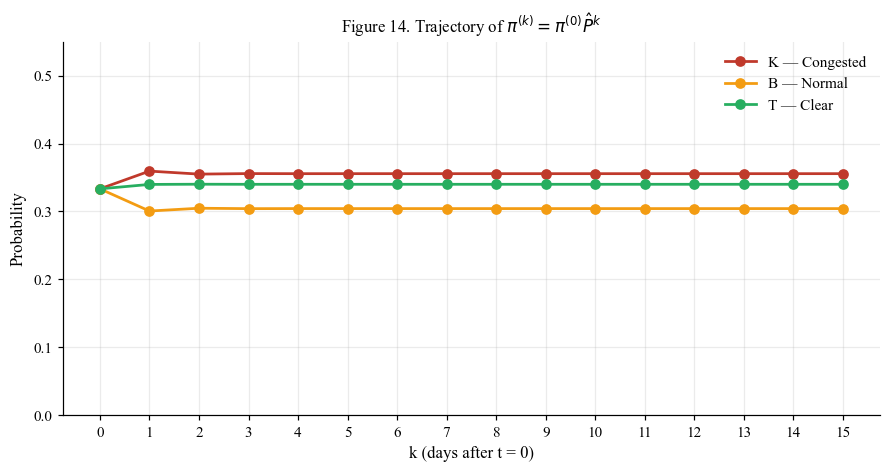

In [26]:
ks = np.arange(0, 16)
path = np.vstack([p0 if k == 0 else prop_distribution(P, k, p0) for k in ks])

fig, ax = plt.subplots(figsize=(8.2, 4.4))
for j, st in enumerate(STATES):
    ax.plot(ks, path[:, j], marker="o", lw=1.8, color=state_color[st],
            label=f"{st} — {STATE_LABEL[st]}")
ax.set_xlabel("k (days after t = 0)")
ax.set_ylabel("Probability")
ax.set_title(r"Figure 14. Trajectory of $\pi^{(k)}=\pi^{(0)}\hat P^k$")
ax.set_xticks(ks)
ax.legend(frameon=False)
ax.set_ylim(0, 0.55)
fig.tight_layout()
plt.show()

## 2.e Stationary distribution: `prop_sta`

We solve $(\hat P^\top-I)\pi^\top=0$ after replacing the last row by the normalisation $\sum_i\pi_i=1$. Consistency is checked against $\pi^{(10)}$ and $\pi^{(50)}$.

In [27]:
pi = prop_sta(P)
print("Stationary distribution π = prop_sta(P):")
for s, v in zip(STATES, pi):
    print(f"  {s} ({STATE_LABEL[s]}): {v:.6f}")
print("Sum:", pi.sum())

gap = np.dot(pi, P) - pi
print("\n‖πP − π‖_∞ =", np.max(np.abs(gap)))

p10 = prop_distribution(P, 10, p0)
p50 = prop_distribution(P, 50, p0)
compare = pd.DataFrame({
    "State": STATES,
    "π": pi,
    "π(10)": p10,
    "π(50)": p50,
    "|π(10) − π|": np.abs(p10 - pi),
    "|π(50) − π|": np.abs(p50 - pi),
})
compare

Stationary distribution π = prop_sta(P):
  K (Congested): 0.355705
  B (Normal): 0.304251
  T (Clear): 0.340045
Sum: 1.0

‖πP − π‖_∞ = 5.551115123125783e-17


,State,π,π(10),π(50),|π(10) − π|,|π(50) − π|
0,K,0.3557,0.3557,0.3557,0.0000,0.0000
1,B,0.3043,0.3043,0.3043,0.0000,0.0000
2,T,0.3400,0.3400,0.3400,0.0000,0.0000


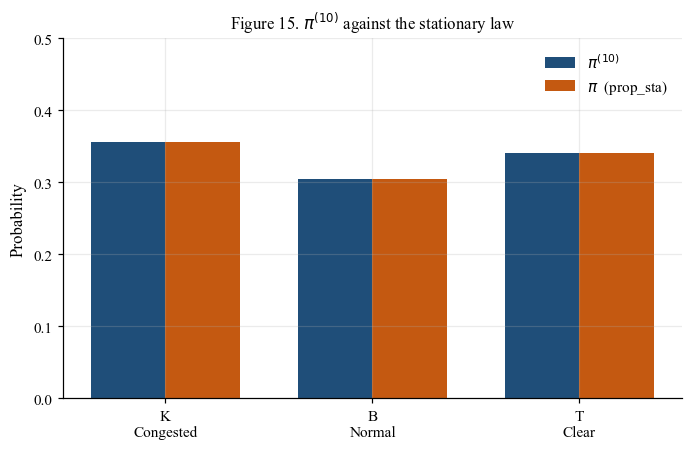

In [28]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
x = np.arange(3)
w = 0.36
ax.bar(x - w / 2, prop_distribution(P, 10, p0), width=w, color=C_MAIN, label=r"$\pi^{(10)}$")
ax.bar(x + w / 2, pi, width=w, color=C_ACCENT, label=r"$\pi$  (prop_sta)")
ax.set_xticks(x, [f"{s}\n{STATE_LABEL[s]}" for s in STATES])
ax.set_ylabel("Probability")
ax.set_title(r"Figure 15. $\pi^{(10)}$ against the stationary law")
ax.legend(frameon=False)
ax.set_ylim(0, 0.5)
fig.tight_layout()
plt.show()

**Result (e).** The linear system is solved to machine precision: $\lVert\pi\hat P-\pi\rVert_\infty$ is of order $10^{-16}$. By day 10 the forward distribution is already indistinguishable from $\pi$ on the plotted scale, as expected for a small, irreducible, aperiodic kernel. Entries of $\hat P$ deviate from $1/3$ only by sampling error induced by 59 transitions from an i.i.d. uniform design. The computational pipeline — counts, row normalisation, `prop_distribution`, `prop_sta` — does not depend on that design and applies unchanged to a serially dependent traffic record.

---

## Concluding remarks

On the Stockton sample, living area is the first-order determinant of selling price. A linear model in all six covariates improves the residual, and a quadratic specification with two interactions improves it further, at the cost of remaining in-sample. Heteroscedasticity in the upper tail is not removed. On the traffic exercise, the finite-horizon and stationary laws of the estimated three-state chain are well-defined, internally consistent, and rapidly mixing. Both parts are obtained from the same linear-algebraic primitives: a normal equation for OLS and an eigenvalue constraint for the Markov kernel.